In [1]:
import numpy as np
import pandas as pd
import glob
from helper import *
from define_model import *
from my_helpers import *
from itertools import zip_longest
import pprint as p

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
tf.test.is_built_with_cuda()


True

In [4]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

2023-07-26 19:06:37.708870: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-26 19:06:37.758233: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-26 19:06:37.758494: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [5]:
tf.test.gpu_device_name()

2023-07-26 19:06:39.614605: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-26 19:06:39.616525: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-26 19:06:39.616873: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-26 19:06:39.617100: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zer

'/device:GPU:0'

In [6]:
identifier_eth = "TouchPose_crossGestures"
data_path_eth = "../data/eth_data/"
data_path_chili= "../data/processed/"
model_path = "../models/"

In [10]:
files = glob.glob(data_path_eth+'*.pkl')
df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)

In [11]:
control = 'gesture'
df_group = df.groupby([control])[["cap_img","skeleton"]]
g_id = list(df_group.groups.keys())
p.pprint(control)
p.pprint(df_group)
p.pprint(g_id) 

KeyError: 'gesture'

In [11]:
depth_err = []
for i in range(len(g_id)):
    test_set = [g_id[i]]
    X_test_cap, Y_test_depth= get_data_splits(df_group,test_set)
    model = get_model(identifier, model_path, test_set)
    Y_out_depth = model.predict(X_test_cap, batch_size=32)
    depth_error = np.mean(abs(Y_test_depth - Y_out_depth[:,:,:,0])) * 255
    depth_err.append(depth_error)
    print("Accuracy", g_id[i],depth_error)
    break


2023-07-24 11:00:43.779460: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4906 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1060, pci bus id: 0000:01:00.0, compute capability: 6.1
2023-07-24 11:00:45.206359: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8204


Accuracy 65.0 30.418465185291673


# Partially load model

In [12]:
model.layers

In [13]:
multi_task_model = create_MultiTaskTouchPoseNet(41, 72, 1)

## Now we will assign weights to multi task model from depth model

In [14]:
match = []
for depth_layer, multi_layer, matching in zip_longest(model.layers,multi_task_model.layers,range(len(multi_task_model.layers)),fillvalue='0'):
        if(depth_layer!='0'):
            match.append((depth_layer.name, multi_layer.name, (matching,matching)))
        else : 
            match.append((depth_layer, multi_layer.name,(matching,matching)))
match

[('input_25', 'input_1', (0, 0)),
 ('conv2d_336', 'conv2d', (1, 1)),
 ('conv2d_337', 'conv2d_1', (2, 2)),
 ('max_pooling2d_72', 'max_pooling2d', (3, 3)),
 ('conv2d_338', 'conv2d_2', (4, 4)),
 ('conv2d_339', 'conv2d_3', (5, 5)),
 ('max_pooling2d_73', 'max_pooling2d_1', (6, 6)),
 ('conv2d_340', 'conv2d_4', (7, 7)),
 ('conv2d_341', 'conv2d_5', (8, 8)),
 ('max_pooling2d_74', 'max_pooling2d_2', (9, 9)),
 ('conv2d_342', 'conv2d_6', (10, 10)),
 ('conv2d_343', 'conv2d_7', (11, 11)),
 ('up_sampling2d_72', 'up_sampling2d', (12, 12)),
 ('concatenate_72', 'concatenate', (13, 13)),
 ('conv2d_344', 'conv2d_8', (14, 14)),
 ('conv2d_345', 'conv2d_9', (15, 15)),
 ('up_sampling2d_73', 'up_sampling2d_1', (16, 16)),
 ('concatenate_73', 'concatenate_1', (17, 17)),
 ('conv2d_346', 'conv2d_10', (18, 18)),
 ('conv2d_347', 'flatten', (19, 19)),
 ('up_sampling2d_74', 'conv2d_11', (20, 20)),
 ('tf.compat.v1.pad_24', 'dense', (21, 21)),
 ('concatenate_74', 'up_sampling2d_2', (22, 22)),
 ('conv2d_348', 'activation

In [15]:
match = [ (''.join([ xi for xi in x[0] if not (xi.isdigit() or xi== '_')]),''.join([ xi for xi in x[1] if not (xi.isdigit() or xi== '_')]), x[2]) for x in match]
bad_match = [x for x in match if x[0]!=x[1]]
bad_match

[('convd', 'flatten', (19, 19)),
 ('upsamplingd', 'convd', (20, 20)),
 ('tf.compat.v.pad', 'dense', (21, 21)),
 ('concatenate', 'upsamplingd', (22, 22)),
 ('convd', 'activation', (23, 23)),
 ('convd', 'tf.compat.v.pad', (24, 24)),
 ('regressiondepth', 'batchnormalization', (25, 25)),
 ('', 'concatenate', (26, 26)),
 ('', 'dropout', (27, 27)),
 ('', 'convd', (28, 28)),
 ('', 'dense', (29, 29)),
 ('', 'convd', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regressiondepth', (33, 33))]

In [16]:
bad_match_sec = bad_match.copy()

for i in range(len(bad_match)):
    for j in range(len(bad_match_sec)):
        if bad_match[i][0]==bad_match_sec[j][1]:
            new_match = list(bad_match[i])
            new_match[1] = bad_match_sec[j][1]
            new_match[2] = (bad_match[i][2][0],bad_match_sec[j][2][1])
            bad_match[i] = tuple(new_match)
            bad_match_sec.remove(bad_match_sec[j])
            break

bad_match

[('convd', 'convd', (19, 20)),
 ('upsamplingd', 'upsamplingd', (20, 22)),
 ('tf.compat.v.pad', 'tf.compat.v.pad', (21, 24)),
 ('concatenate', 'concatenate', (22, 26)),
 ('convd', 'convd', (23, 28)),
 ('convd', 'convd', (24, 30)),
 ('regressiondepth', 'regressiondepth', (25, 33)),
 ('', 'concatenate', (26, 26)),
 ('', 'dropout', (27, 27)),
 ('', 'convd', (28, 28)),
 ('', 'dense', (29, 29)),
 ('', 'convd', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regressiondepth', (33, 33))]

In [17]:
good_match = [x for x in match if x[0]==x[1]]
match = [x for x in good_match + bad_match if x[0]==x[1]]
match

[('input', 'input', (0, 0)),
 ('convd', 'convd', (1, 1)),
 ('convd', 'convd', (2, 2)),
 ('maxpoolingd', 'maxpoolingd', (3, 3)),
 ('convd', 'convd', (4, 4)),
 ('convd', 'convd', (5, 5)),
 ('maxpoolingd', 'maxpoolingd', (6, 6)),
 ('convd', 'convd', (7, 7)),
 ('convd', 'convd', (8, 8)),
 ('maxpoolingd', 'maxpoolingd', (9, 9)),
 ('convd', 'convd', (10, 10)),
 ('convd', 'convd', (11, 11)),
 ('upsamplingd', 'upsamplingd', (12, 12)),
 ('concatenate', 'concatenate', (13, 13)),
 ('convd', 'convd', (14, 14)),
 ('convd', 'convd', (15, 15)),
 ('upsamplingd', 'upsamplingd', (16, 16)),
 ('concatenate', 'concatenate', (17, 17)),
 ('convd', 'convd', (18, 18)),
 ('convd', 'convd', (19, 20)),
 ('upsamplingd', 'upsamplingd', (20, 22)),
 ('tf.compat.v.pad', 'tf.compat.v.pad', (21, 24)),
 ('concatenate', 'concatenate', (22, 26)),
 ('convd', 'convd', (23, 28)),
 ('convd', 'convd', (24, 30)),
 ('regressiondepth', 'regressiondepth', (25, 33))]

For now keep bottleneck, check later for both


In [18]:
for i in range(len(model.layers)):
    d = match[i][2][0]
    m = match[i][2][1]
    multi_task_model.layers[m].set_weights(model.layers[d].get_weights())

## Model is partially loaded

In [19]:
p.pprint(model.input)
print('multi model')
p.pprint(multi_task_model.input)

<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'input_25')>
multi model
<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'input_1')>


In [20]:
p.pprint(model.output)
print('multi model')
p.pprint(multi_task_model.output)


<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'regression_depth')>
multi model
[<KerasTensor: shape=(None, 63) dtype=float32 (created by layer 'regression')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'visibility')>,
 <KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'regression_depth')>]


In [23]:
cap_img = read_cap_img(new_data+"/Arish_1_UP_100_rawdata.csv")
skeleton = read_skeleton(new_data+"/userarish_2023-04-03_10-10-07_11956_handleap.csv")

In [24]:
skeleton.Timestamp = skeleton.Timestamp.astype('int64')*1000
cap_img = cap_img.rename(columns={'TimeStamps': 'Timestamp'})
cap_img.head()

,Timestamp,MergeTimeStamps,ScanSizeX,ScanSizeY,img
0,1680508053473,1680508053470,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1680508053489,1680508053485,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,1680508053506,1680508053505,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1680508053519,1680508053515,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1680508053532,1680508053530,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [25]:
both=pd.merge(skeleton, cap_img[['img','Timestamp']], on='Timestamp', how='inner') 
print(len(both))
both.columns

347


Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Index_0_x', 'Index_0_y', 'Index_0_z', 'Index_1_x', 'Index_1_y',
       'Index_1_z', 'Index_2_x', 'Index_2_y', 'Index_2_z', 'Index_3_x',
       'Index_3_y', 'Index_3_z', 'Middle_0_x', 'Middle_0_y', 'Middle_0_z',
       'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x', 'Middle_2_y',
       'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z', 'Ring_0_x',
       'Ring_0_y', 'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x',
       'Ring_2_y', 'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Pinky_0_x',
       'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x', 'Pinky_1_y', 'Pinky_1_z',
       'Pinky_2_x', 'Pinky_2_y', 'Pinky_2_z', 'Pinky_3_x', 'Pinky_3_y',
       'Pinky_3_z', 'img'],
      dtype='object')

In [26]:
input = prepare_input(both)
input.shape

(347, 41, 72)

In [27]:
ys=multi_task_model.predict(input, batch_size=128)

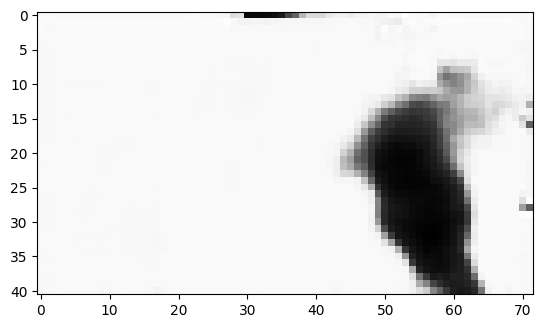

In [28]:
plt.imshow(ys[2][0], cmap='gray')

Same Direcly predict on some test data

In [29]:
#data = pd.read_pickle(our_data+'/day0.pkl')

In [30]:
ys = multi_task_model.predict(input, batch_size=128)

In [31]:
real_hand=data.skeleton.iloc[0]
real_hand

NameError: name 'data' is not defined

In [49]:
pred_hand=ys[0][0].reshape(21,3)
pred_hand

array([[  8.046144  , -32.864292  ,  13.823027  ],
       [-16.6199    , -49.528263  ,  -9.048891  ],
       [ 12.713009  ,  27.72156   ,  -0.8500514 ],
       [ -2.3406312 ,   8.681313  , -47.210636  ],
       [-18.52155   ,   3.098228  , -31.210331  ],
       [ 39.31544   , -40.17692   ,  -0.3415031 ],
       [ 24.7884    ,  65.590836  ,  13.358595  ],
       [ 39.802788  ,  -3.083434  ,   4.5301423 ],
       [ 33.158672  ,  34.263573  ,  -0.27145526],
       [ -0.8604934 ,  36.47908   ,  27.352741  ],
       [-26.147583  ,  15.017345  ,   5.313227  ],
       [-61.740334  ,  39.483192  ,  -5.5981126 ],
       [-59.140957  ,  19.628805  ,  46.101707  ],
       [-13.728282  ,   6.4941716 ,  32.27433   ],
       [ 10.723272  ,   4.0226398 , -35.61694   ],
       [ 19.135775  ,  37.714176  ,  12.197509  ],
       [-10.003893  ,  52.72066   , -23.20218   ],
       [-14.392584  ,   6.708242  ,  35.028194  ],
       [ 47.695194  ,  11.825575  , -10.557387  ],
       [  2.19106   ,  -0.58492

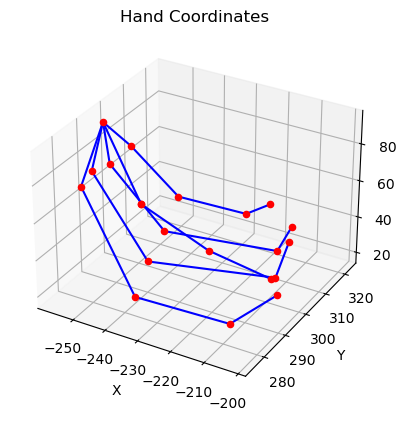

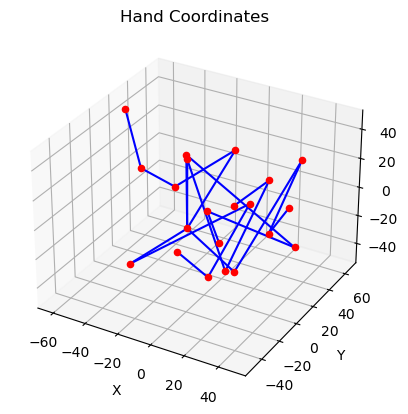

In [50]:
plot_hand(real_hand)
plot_hand(pred_hand)

# Test the model before training

In [36]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)

In [37]:
chili_data.day.unique()

array([4, 0, 3, 1], dtype=object)

In [43]:
chili_control = 'gesture'
chili_group = chili_data.groupby([control])[["cap_img","skeleton"]]
chili_id = list(chili_group.groups.keys())

In [85]:
chili_data

,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.680093e+12,"[[-270, 288, 68], [-242, 276, 55], [-242, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680093e+12,"[[-270, 288, 68], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680093e+12,"[[-270, 288, 67], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680093e+12,"[[-270, 288, 67], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680093e+12,"[[-270, 288, 67], [-242, 276, 54], [-242, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...,...,...,...,...
24028,1.680267e+12,"[[-280, 292, 156], [-265, 278, 126], [-265, 27...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
24029,1.680267e+12,"[[-281, 293, 155], [-266, 280, 124], [-266, 28...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
24030,1.680267e+12,"[[-281, 293, 154], [-266, 280, 123], [-266, 28...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
24031,1.680267e+12,"[[-282, 294, 153], [-267, 281, 122], [-267, 28...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [44]:
print(chili_control)
print(chili_group) # group by gesture_id
print(chili_id) # list of gesture_id

gesture
['DQ', 'DT', 'LQ', 'LT', 'UP']


In [45]:
control = id_key[identifier]
df_group = df.groupby([control])[["cap_img","depth_img"]]
g_id = list(df_group.groups.keys())

In [46]:
print(control)
print(df_group) # group by gesture_id
print(g_id) # list of gesture_id

gesture_id
[65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0]


In [71]:

def data_splits(df, id_arr):
    X_cap, Y_skeleton = None, None
    for p_id in id_arr:
        df_extract = df.get_group(p_id)
        x_cap_img = np.array(df_extract["cap_img"].tolist())
        y_skeleton = np.array(df_extract["skeleton"].tolist()).reshape(-1,63)

        x_cap_img[x_cap_img < 0] = 0
        maxVal = 3023
        x_cap_img = x_cap_img/maxVal

        if X_cap is None:
            X_cap = x_cap_img
            Y_skeleton = y_skeleton
        else:
            X_cap = np.vstack((X_cap, x_cap_img))
            Y_skeleton = np.vstack((Y_skeleton, y_skeleton))
    return X_cap, Y_skeleton

skeleton_err = []


for i in range(len(chili_id)):
    test_set = [chili_id[i]]
    X_test_cap, Y_test_skeleton= data_splits(chili_group,test_set)
    Y_out_skeleton = multi_task_model.predict(X_test_cap, batch_size=32)
    skeleton_error = np.mean(abs(Y_test_skeleton - Y_out_skeleton[0])) 
    skeleton_err.append(skeleton_error)
    print("Accuracy", chili_id[i],skeleton_error)


Accuracy DQ 212.15281655496415
Accuracy DT 218.92334752196857
Accuracy LQ 204.58294058142005
Accuracy LT 199.60808355692618


2023-07-24 11:23:24.184866: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 112471200 exceeds 10% of free system memory.
2023-07-24 11:23:24.269052: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 112471200 exceeds 10% of free system memory.


Accuracy UP 209.98871592473066


2023-07-24 11:23:29.947364: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 112471200 exceeds 10% of free system memory.


In [1]:
Y_out_depth

NameError: name 'Y_out_depth' is not defined

# Train the model

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Assuming you have your dataset stored in variables: X_img, X_skeleton, Y_skeleton

# Data preprocessing
X_img = np.array(...)  # Capacitive image data
X_skeleton = np.array(...)  # Skeleton data
Y_skeleton = np.array(...)  # Target skeleton data

# Normalize input data
X_img = X_img / 255.0

# Reshape input data
X_img = X_img.reshape(-1, 41, 72, 1)

# Split dataset into training and validation sets
X_img_train, X_img_val, X_skeleton_train, X_skeleton_val, Y_skeleton_train, Y_skeleton_val = train_test_split(
    X_img, X_skeleton, Y_skeleton, test_size=0.2, random_state=42)

In [72]:
chili_data

,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.680093e+12,"[[-270, 288, 68], [-242, 276, 55], [-242, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.680093e+12,"[[-270, 288, 68], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.680093e+12,"[[-270, 288, 67], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.680093e+12,"[[-270, 288, 67], [-243, 276, 54], [-243, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.680093e+12,"[[-270, 288, 67], [-242, 276, 54], [-242, 276,...",72,41,1,UP,32,4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
...,...,...,...,...,...,...,...,...,...
24028,1.680267e+12,"[[-280, 292, 156], [-265, 278, 126], [-265, 27...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
24029,1.680267e+12,"[[-281, 293, 155], [-266, 280, 124], [-266, 28...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
24030,1.680267e+12,"[[-281, 293, 154], [-266, 280, 123], [-266, 28...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
24031,1.680267e+12,"[[-282, 294, 153], [-267, 281, 122], [-267, 28...",72,41,6,UP,13,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [84]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Define the 'dummy_loss' function as a placeholder loss for the missing visibility output
# Define the 'dummy_loss' function as a placeholder loss for the missing visibility output
def dummy_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  # Cast the true labels to float32
    y_pred = tf.cast(y_pred, tf.float32)  # Cast the predicted labels to float32
    return tf.reduce_sum(y_pred - y_true)  # Use any dummy loss, this will not affect the actual training
  # Use any dummy loss, this will not affect the actual training

# Function to extract and process data for training
def data_splits(df):
    X_cap, Y_skeleton = [], []
    for _, row in df.iterrows():
        x_cap_img = np.array(row['cap_img'])
        y_skeleton = np.array(row['skeleton']).reshape(-1, 63)

        x_cap_img[x_cap_img < 0] = 0
        maxVal = 3023
        x_cap_img = x_cap_img / maxVal

        X_cap.append(x_cap_img)
        Y_skeleton.append(y_skeleton)

    X_cap = np.stack(X_cap)  # Convert list of arrays into a single numpy array
    Y_skeleton = np.stack(Y_skeleton)  # Convert list of arrays into a single numpy array

    return X_cap, Y_skeleton

# Assuming you have already defined the 'multi_task_model' and loaded the pre-trained weights
# Compile the model with appropriate loss functions and optimizers before starting the training loop
multi_task_model.compile(
    optimizer='adam',
    loss=['mean_squared_error', dummy_loss, 'mean_squared_error']
)

# Load your DataFrame (df) containing the data
# ...

# Split the data into train and test sets
train_data, test_data = train_test_split(chili_data, test_size=0.2, random_state=42)

# Extract training and testing data
X_train_cap, Y_train_skeleton = data_splits(train_data)
X_test_cap, Y_test_skeleton = data_splits(test_data)

# Training parameters
batch_size = 32
epochs = 10

# Create a TensorBoard callback
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="./logs", histogram_freq=1)

# Training loop
multi_task_model.fit(
    X_train_cap,
    [Y_train_skeleton, Y_train_skeleton],  # Use Y_train_skeleton twice since there are only two output layers
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test_cap, [Y_test_skeleton, Y_test_skeleton]),  # Use Y_test_skeleton twice for validation
    callbacks=[tensorboard_callback]
)

# Save the trained model
multi_task_model.save('trained_multi_task_model.h5')


Epoch 1/10


ValueError: in user code:

    File "/home/yassine/anaconda3/envs/env_gpu/lib/python3.8/site-packages/keras/engine/training.py", line 1021, in train_function  *
        return step_function(self, iterator)
    File "/home/yassine/anaconda3/envs/env_gpu/lib/python3.8/site-packages/keras/engine/training.py", line 1010, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/yassine/anaconda3/envs/env_gpu/lib/python3.8/site-packages/keras/engine/training.py", line 1000, in run_step  **
        outputs = model.train_step(data)
    File "/home/yassine/anaconda3/envs/env_gpu/lib/python3.8/site-packages/keras/engine/training.py", line 864, in train_step
        return self.compute_metrics(x, y, y_pred, sample_weight)
    File "/home/yassine/anaconda3/envs/env_gpu/lib/python3.8/site-packages/keras/engine/training.py", line 957, in compute_metrics
        self.compiled_metrics.update_state(y, y_pred, sample_weight)
    File "/home/yassine/ana